# Confronto tra i diversi algoritmi di integrazione

In [7]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

def plot_xvE(base_folder, filename, folders, legend_loc='upper left'):
    # --- Publication Quality Styling ---
    plt.rcParams.update({
        "font.family": "serif",       
        "font.size": 11,              
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
        "text.usetex": False          
    })

    display_labels = {}
    for folder in folders:
        # Extract the '1e-1' part from 'DT_1e-1'
        raw_num = folder.split('_')[1]  # returns "1e-1"
        
        # Split by 'e' to get the base and the exponent
        base, exponent = raw_num.split('e') # base="1", exponent="-1"
        
        # Strip any leading zeros or plus signs from the exponent, keeping it clean
        exponent = int(exponent) 
        
        # Format as a raw LaTeX string for Matplotlib
        display_labels[folder] = rf'$\Delta t = 10^{{{exponent}}}$'
    
    # Explicitly define the column schema
    # This bypasses the skipped header and maps directly to the data rows
    column_names = ['t', 'x', 'v', 'E', 'x_th', 'v_th', 'E_th']
    
    fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
    
    for i, folder in enumerate(folders):
        file_path = os.path.join(base_folder, folder, filename)
        
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found. Skipping.")
            continue
            
        # By passing 'names', pandas ignores all '#' lines but knows exactly 
        # what to call your dataset columns.
        df = pd.read_csv(file_path, sep=r'\s+', comment='#', names=column_names)
    
        # Plot theoretical curve once
        if i == 0:
            theory_style = {'color': 'black', 'linestyle': '--', 'linewidth': 2.0, 'label': 'Teoria', 'zorder': 5}
            axs[0].plot(df['t'], df['x_th'], **theory_style)
            axs[1].plot(df['t'], df['v_th'], **theory_style)
            axs[2].plot(df['t'], df['E_th'], **theory_style)
        
        # Plot experimental data
        axs[0].plot(df['t'], df['x'], label=display_labels[folder], linewidth=1.5)
        axs[1].plot(df['t'], df['v'], label=display_labels[folder], linewidth=1.5)
        axs[2].plot(df['t'], df['E'], label=display_labels[folder], linewidth=1.5)
    
    # --- Aesthetic Refinements ---
    axs[0].set_ylabel(r'Posizione $x(t)$')
    axs[1].set_ylabel(r'Velocità $v(t)$')
    axs[2].set_ylabel(r'Energia $E(t)$')
    axs[2].set_xlabel(r'Tempo $t$')
    
    for ax in axs:
        ax.set_xlim(df['t'].min(), df['t'].max())
        ax.grid(True, linestyle=':', alpha=0.6, color='gray')
        ax.tick_params(direction='in', which='major', top=True, right=True)
        
        # Keep axis intervals tight and clean
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
    
    axs[2].legend(loc=legend_loc, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)
    
    plt.subplots_adjust(hspace=0.0)
    
    #output_name = filename.split(".")[0] + ".png"
    #plt.savefig(output_name, dpi=300, bbox_inches='tight')
    #plt.show()
    return fig

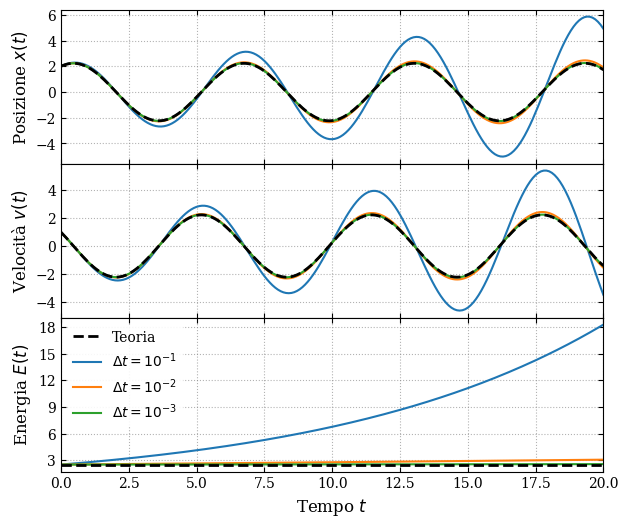

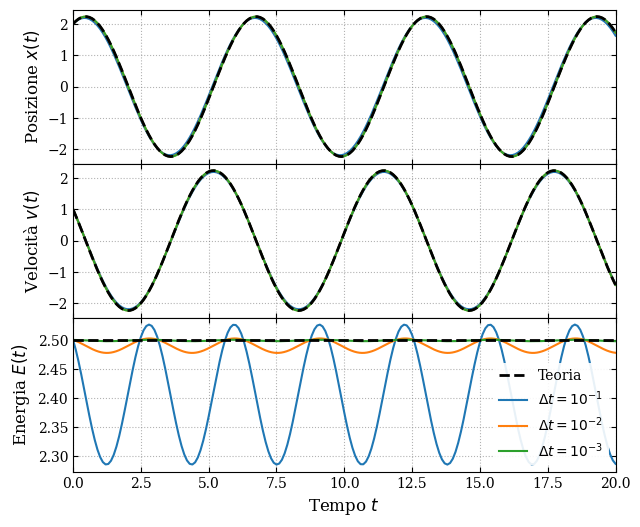

In [18]:
fig_eulero = plot_xvE(base_folder="../../../CODICI/HARMONIC_OSCILLATOR", filename="res_eulero.dat", folders=['DT_1e-1', 'DT_1e-2', 'DT_1e-3'])
fig_eulero_cromer = plot_xvE(base_folder="../../../CODICI/HARMONIC_OSCILLATOR", filename="res_eulero_cromer.dat", folders=['DT_1e-1', 'DT_1e-2', 'DT_1e-3'], legend_loc="best")

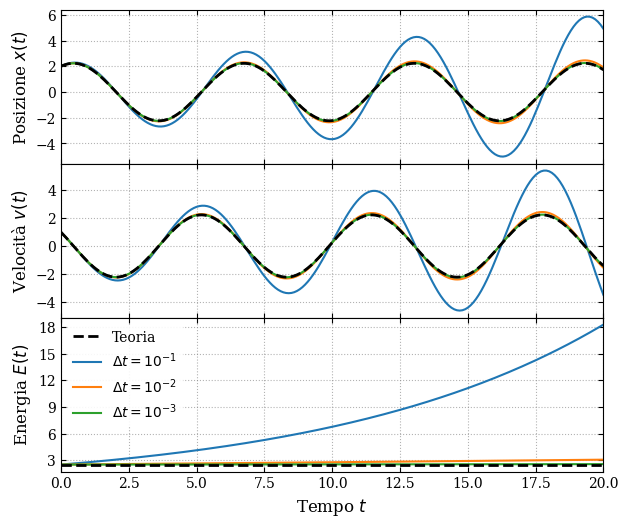

In [24]:
#| label: cell:res_eulero
fig_eulero

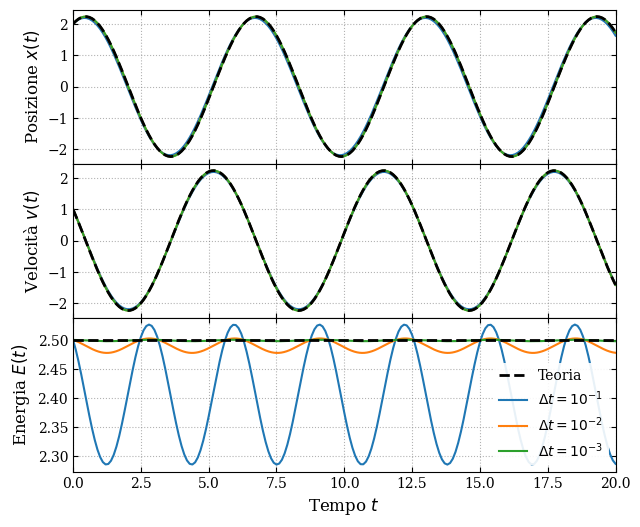

In [25]:
#| label: cell:res_eulero_cromer
fig_eulero_cromer